# Traffic Volume Prediction — Model Training & Comparison

This notebook trains and compares three regression models — **Linear Regression**, **Random Forest**, and **XGBoost** — to predict traffic volume, then selects the best performing model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

## 1. Load the Data

Read the cleaned traffic volume dataset and take a quick look at its structure.

In [2]:
df = pd.read_csv("traffic_volume_cleaned.csv")
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,traffic_volume,hour,day_of_week,month,hour_sin,hour_cos,month_sin,month_cos
0,Not Holiday,288.28,0.0,0.0,40,Clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,7.071068e-01,-0.707107,-0.866025,0.5
1,Not Holiday,289.36,0.0,0.0,75,Clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,5.000000e-01,-0.866025,-0.866025,0.5
2,Not Holiday,289.58,0.0,0.0,90,Clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,2.588190e-01,-0.965926,-0.866025,0.5
3,Not Holiday,290.13,0.0,0.0,90,Clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,1.224647e-16,-1.000000,-0.866025,0.5
4,Not Holiday,291.14,0.0,0.0,75,Clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,-2.588190e-01,-0.965926,-0.866025,0.5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40564 entries, 0 to 40563
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   holiday         40564 non-null  str    
 1   temp            40564 non-null  float64
 2   rain_1h         40564 non-null  float64
 3   snow_1h         40564 non-null  float64
 4   clouds_all      40564 non-null  int64  
 5   weather_main    40564 non-null  str    
 6   date_time       40564 non-null  str    
 7   traffic_volume  40564 non-null  int64  
 8   hour            40564 non-null  int64  
 9   day_of_week     40564 non-null  str    
 10  month           40564 non-null  int64  
 11  hour_sin        40564 non-null  float64
 12  hour_cos        40564 non-null  float64
 13  month_sin       40564 non-null  float64
 14  month_cos       40564 non-null  float64
dtypes: float64(7), int64(4), str(4)
memory usage: 4.6 MB


## 2. Feature Engineering

Convert `date_time` to a proper datetime type, sort the data chronologically, and derive the `year` and numeric day-of-week fields. The day-of-week is then cyclically encoded with sine/cosine so the model understands that day 6 (Sunday) and day 0 (Monday) are close together, matching the encoding already applied to `hour` and `month`.

In [4]:
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

df["year"] = df["date_time"].dt.year
df["day_of_week_num"] = df["date_time"].dt.dayofweek

In [5]:
df["day_sin"] = np.sin(2 * np.pi * df["day_of_week_num"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week_num"] / 7)

## 3. Encode the Holiday Column

`holiday` is converted into a simple binary flag: `1` if the day is a holiday, `0` otherwise.

In [6]:
df["holiday"] = df["holiday"].apply(lambda x: 0 if x == "Not Holiday" else 1)
df["holiday"].value_counts()

holiday
0    39361
1     1203
Name: count, dtype: int64

## 4. Define Features and Target

Separate the predictors (`X`) from the target variable (`traffic_volume`), dropping columns that are either redundant (already cyclically encoded, e.g. raw `hour`/`month`) or not usable directly by the models (`date_time`, string `day_of_week`).

In [7]:
X = df.drop(columns=["traffic_volume", "date_time", "hour", "month", "day_of_week", "day_of_week_num"])
y = df["traffic_volume"]

X.columns.tolist()

['holiday',
 'temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'weather_main',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos',
 'year',
 'day_sin',
 'day_cos']

## 5. Train / Test Split

Since this is time-ordered traffic data, a chronological split is used instead of a random split: the earliest 80% of records train the models and the most recent 20% test them, simulating how the model would be used in practice (predicting the future from the past).

In [8]:
split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 32451
Testing samples: 8113


## 6. Preprocessing Pipeline

Numerical features are standardized and the categorical `weather_main` column is one-hot encoded. This preprocessing step is shared across all three model pipelines.

In [9]:
categorical_features = ["weather_main"]

numerical_features = [
    "holiday", "temp", "rain_1h", "snow_1h", "clouds_all", "year",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "day_sin", "day_cos"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

## 7. Build the Model Pipelines

Each model — Linear Regression, Random Forest, and XGBoost — is wrapped in its own pipeline together with the shared preprocessor.

In [10]:
models = {
    "Linear Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1))
    ])
}

## 8. Train and Evaluate Each Model

Every model is fit on the training set and evaluated on the held-out test set using MAE, RMSE, and R².

In [11]:
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

In [12]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,XGBoost,241.991089,397.126849,0.959372
1,Random Forest,254.119600,419.869348,0.954585
2,Linear Regression,837.643736,1077.509495,0.700904


## 9. Compare the Models Visually

A side-by-side bar chart of RMSE and R² makes it easy to see which model generalizes best to unseen data.

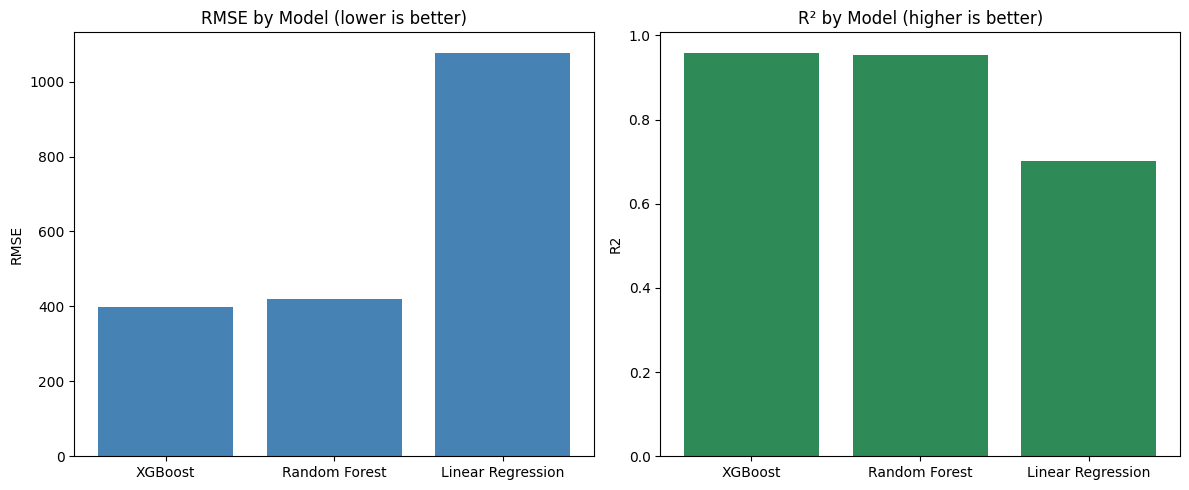

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df["Model"], results_df["RMSE"], color="steelblue")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].set_ylabel("RMSE")

axes[1].bar(results_df["Model"], results_df["R2"], color="seagreen")
axes[1].set_title("R² by Model (higher is better)")
axes[1].set_ylabel("R2")

plt.tight_layout()
plt.show()

## 10. Select the Best Model

The model with the highest R² (and correspondingly lowest error) on the test set is selected as the final choice.

In [14]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best performing model: {best_model_name}")
results_df

Best performing model: XGBoost


,Model,MAE,RMSE,R2
0,XGBoost,241.991089,397.126849,0.959372
1,Random Forest,254.119600,419.869348,0.954585
2,Linear Regression,837.643736,1077.509495,0.700904
